# Fourier decomposition of daily returns
Treat adjusted daily log returns as a discrete-time signal. Split the FFT coefficients into three period bands and reconstruct each with `irfft`.

$$r[t]=\log P[t]-\log P[t-1],\qquad x[n]=r[n]-\bar r.$$

The decomposition uses the whole selected sample. It is offline: a reconstructed value can depend on later observations. Sampling is in trading observations, not calendar days.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.data import download_prices, compute_log_returns

plt.rcParams.update({"axes.grid": True, "font.size": 10})
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

Parameters are ordinary notebook variables. `END` is exclusive. Keep the same sample and band boundaries in notebook 02. Change `TICKER` to `AAPL` to run another example; figures use the currently selected ticker.

In [2]:
TICKER = "SPY"
START = "2015-01-01"
END = "2026-10-03"
LOW_PERIOD = 60
HIGH_PERIOD = 10
DISPLAY_DAYS = 252
REFRESH = False

`download_prices` requests adjusted Close with `auto_adjust=True`. The CSV avoids repeated downloads; set `REFRESH=True` to replace it. `pd.read_csv` parses the date column as the index. `np.log(prices).diff()` takes consecutive log differences; only the undefined first return is removed. Missing or nonpositive prices are rejected, not filled.

In [3]:
price_file = ROOT / "data" / f"{TICKER}_{START}_{END}.csv"
price_file.parent.mkdir(exist_ok=True)
if REFRESH or not price_file.exists():
    prices = download_prices(TICKER, START, END)
    prices.to_csv(price_file)
else:
    table = pd.read_csv(price_file, index_col="date", parse_dates=["date"])
    prices = table[TICKER]

returns = compute_log_returns(prices)
print(f"{TICKER}: {len(returns)} returns, {returns.index[0].date()} to {returns.index[-1].date()}")

SPY: 2954 returns, 2015-01-05 to 2026-10-02


## 1. Returns → Fourier coefficients
`to_numpy()` gives a real array of shape `(N,)`. `np.fft.rfft(x)` returns `N//2 + 1` complex coefficients, including DC and, for even N, Nyquist. `np.abs(X)**2` is Fourier power.

`np.fft.rfftfreq(N, d=1)` gives cycles per trading day. For k>0, $f_k=k/N$ and $T_k=N/k=1/f_k$. `np.full` initializes an array; DC gets an infinite period and is excluded from all masks.

Strang's forward transform uses $e^{+i2\pi kn/N}$; NumPy uses the negative sign. For real input the coefficients are conjugated, so magnitudes and powers agree. Using NumPy `rfft` and `irfft` consistently reconstructs the same signal.

In [4]:
r = returns.to_numpy()
N = len(r)
mean_return = r.mean()
x = r - mean_return
X = np.fft.rfft(x)
power = np.abs(X) ** 2
p = power / power.sum()
assert np.isclose(p.sum(), 1)

frequencies = np.fft.rfftfreq(N, d=1)
periods = np.full(len(frequencies), np.inf)
periods[1:] = 1 / frequencies[1:]
print("x shape:", x.shape, "X shape:", X.shape)

x shape: (2954,) X shape: (1478,)


## 2. Coefficients → period masks
Each mask is a Boolean array with the same shape as X. `&` means elementwise AND. `np.isfinite` excludes DC. The boundaries partition all nonzero bins:

- low: T > 60 trading days
- mid: 10 < T ≤ 60 trading days
- high: 2 ≤ T ≤ 10 trading days

The variables above control the boundaries. There is no taper or padding; a finite sample can spread energy between neighboring bins.

60 trading days approximates a three-month trading horizon; 10 days is a short-horizon boundary. Both are illustrative choices for interpretation, not estimates from the data.

In [5]:
assert 2 < HIGH_PERIOD < LOW_PERIOD
nonzero = np.isfinite(periods)
low_mask = nonzero & (periods > LOW_PERIOD)
mid_mask = (periods > HIGH_PERIOD) & (periods <= LOW_PERIOD)
high_mask = (periods >= 2) & (periods <= HIGH_PERIOD)
masks = np.array([low_mask, mid_mask, high_mask])

assert np.all(masks[:, 1:].sum(axis=0) == 1)
assert not masks[:, 0].any()
print(f"Low: T > {LOW_PERIOD}; mid: {HIGH_PERIOD} < T <= {LOW_PERIOD}; high: 2 <= T <= {HIGH_PERIOD}")

Low: T > 60; mid: 10 < T <= 60; high: 2 <= T <= 10


## 3. Masked coefficients → reconstructed components
`np.where(mask, X, 0)` retains coefficients inside a band and zeros the rest. `irfft(..., n=N)` restores the real signal, including the negative-frequency partners implicitly. Passing `n=N` also preserves the correct length when N is odd.

In [6]:
X_low = np.where(low_mask, X, 0)
X_mid = np.where(mid_mask, X, 0)
X_high = np.where(high_mask, X, 0)

x_low = np.fft.irfft(X_low, n=N)
x_mid = np.fft.irfft(X_mid, n=N)
x_high = np.fft.irfft(X_high, n=N)

`np.max(np.abs(error))` reports the largest reconstruction difference. `np.allclose` checks numerical agreement; `np.isrealobj` checks that the arrays are real. Adding `mean_return` back recovers the original returns.

In [7]:
reconstructed = x_low + x_mid + x_high
max_abs_error = np.max(np.abs(x - reconstructed))
assert np.allclose(x, reconstructed, rtol=0, atol=1e-12)
assert np.allclose(r, reconstructed + mean_return, rtol=0, atol=1e-12)
assert np.isrealobj(x_low) and np.isrealobj(x_mid) and np.isrealobj(x_high)
print(f"Maximum reconstruction error: {max_abs_error:.3e}")

Maximum reconstruction error: 4.163e-17


## 4. Normalized Fourier strength
X[k] is the Fourier coefficient, or projection onto Fourier direction k; |X[k]|² is its squared strength. Normalize with $p_k=|X[k]|^2/\sum_j|X[j]|^2$: each bin's fraction of the total squared magnitude of the retained `rfft` coefficients.

The plot shows 100p[k] against period, excluding DC (approximately zero after demeaning). The shaded regions show the chosen bands.

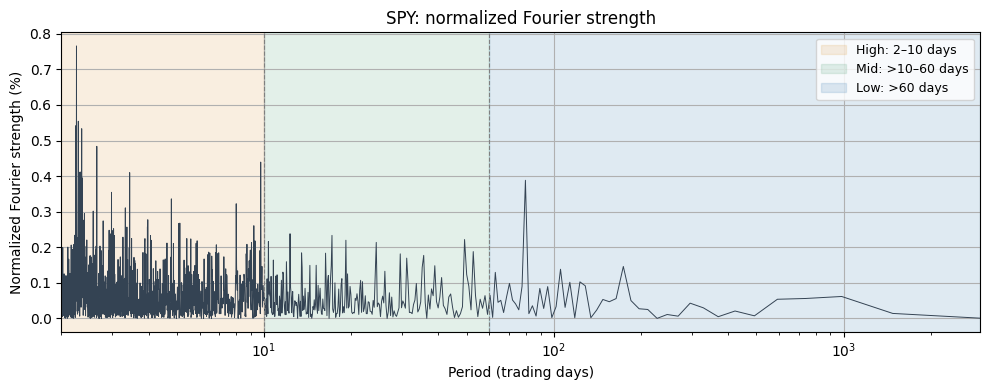

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.axvspan(2, HIGH_PERIOD, color="#df9b43", alpha=0.16, label=f"High: 2–{HIGH_PERIOD} days")
ax.axvspan(HIGH_PERIOD, LOW_PERIOD, color="#55a37a", alpha=0.16, label=f"Mid: >{HIGH_PERIOD}–{LOW_PERIOD} days")
ax.axvspan(LOW_PERIOD, N, color="#397db1", alpha=0.16, label=f"Low: >{LOW_PERIOD} days")
ax.plot(periods[1:], 100 * p[1:], color="#344353", linewidth=0.7)
ax.axvline(HIGH_PERIOD, color="grey", linestyle="--", linewidth=0.8)
ax.axvline(LOW_PERIOD, color="grey", linestyle="--", linewidth=0.8)
ax.set(xscale="log", xlim=(2, N), xlabel="Period (trading days)",
       ylabel="Normalized Fourier strength (%)", title=f"{TICKER}: normalized Fourier strength")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "01_power_spectrum.png", dpi=150)
plt.show()

## 5. Progressive reconstruction
Add the bands in order over the same recent window and with identical vertical limits. The final panel overlays the sum with the original demeaned returns:
$$x[t]=x_{low}[t]+x_{mid}[t]+x_{high}[t].$$
The full-sample FFT assumes periodic extension, so endpoints can show wraparound effects.

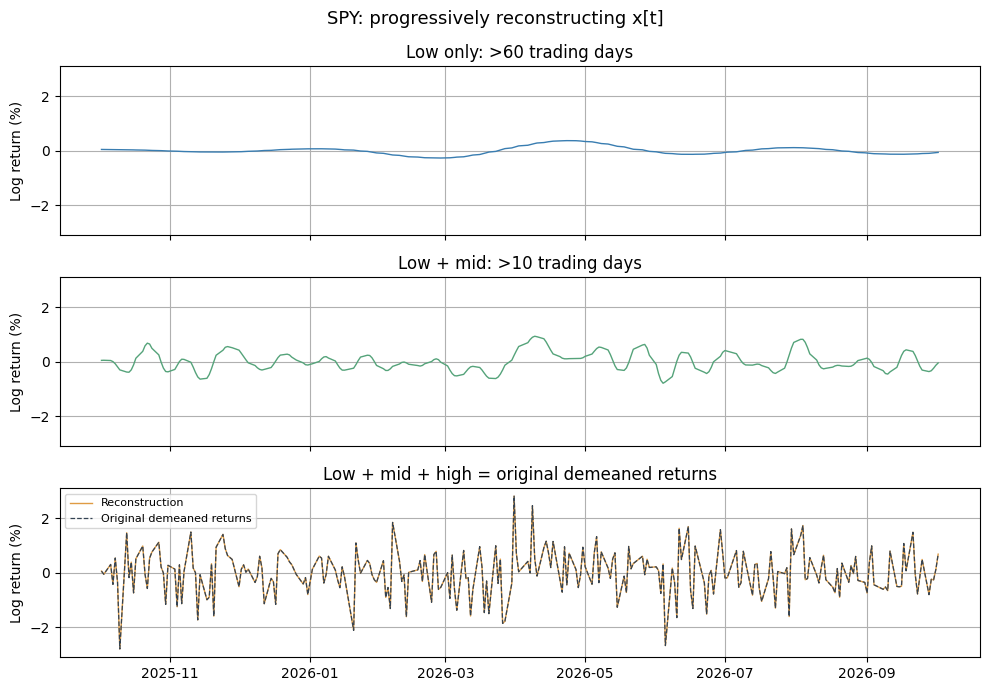

In [9]:
dates = returns.index
view = slice(-DISPLAY_DAYS, None)
low_only = x_low
low_plus_mid = x_low + x_mid
low_plus_mid_plus_high = x_low + x_mid + x_high
series = [low_only, low_plus_mid, low_plus_mid_plus_high]
labels = [f"Low only: >{LOW_PERIOD} trading days",
          f"Low + mid: >{HIGH_PERIOD} trading days", "Low + mid + high = original demeaned returns"]
colors = ["#397db1", "#55a37a", "#df9b43"]
limit = 1.1 * np.max(np.abs(np.array(series)[:, view])) * 100
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, sharey=True)
for ax, values, label, color in zip(axes, series, labels, colors):
    ax.plot(dates[view], values[view] * 100, color=color, linewidth=1, label="Reconstruction")
    ax.set(title=label, ylabel="Log return (%)", ylim=(-limit, limit))
axes[2].plot(dates[view], x[view] * 100, color="#344353", linewidth=0.9,
             linestyle="--", label="Original demeaned returns")
axes[2].legend(fontsize=8)
fig.suptitle(f"{TICKER}: progressively reconstructing x[t]", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES / "02_progressive_reconstruction.png", dpi=150)
plt.show()

## 6. Cumulative contributions
`np.cumsum` takes running sums. Linearity gives $C_x=C_{low}+C_{mid}+C_{high}$.

Accumulation shows a different feature: rapid sign changes tend to cancel, while slower components trace the broad cumulative shape. These are cumulative **demeaned log returns**, not the price path. Each complete Fourier component sums to approximately zero over the full sample.

In [10]:
C_original = np.cumsum(x)
C_low = np.cumsum(x_low)
C_mid = np.cumsum(x_mid)
C_high = np.cumsum(x_high)
C_reconstructed = C_low + C_mid + C_high

cumulative_error = np.max(np.abs(C_original - C_reconstructed))
assert np.allclose(C_original, C_reconstructed, rtol=0, atol=1e-11)
print(f"Maximum cumulative reconstruction error: {cumulative_error:.3e}")

Maximum cumulative reconstruction error: 3.067e-15


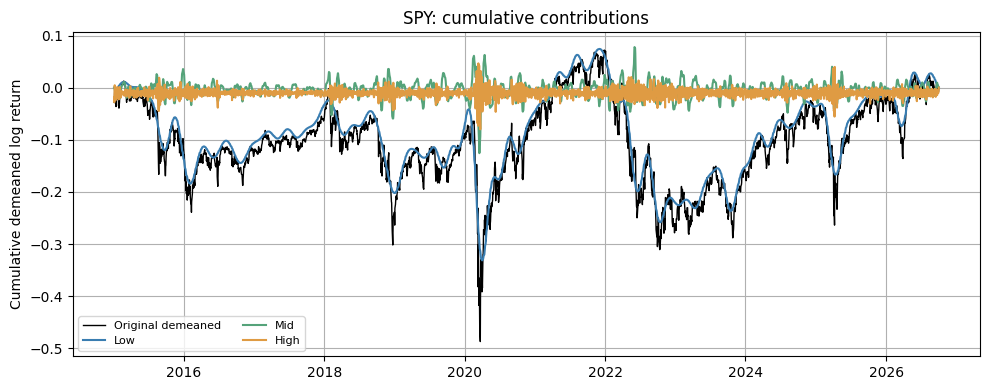

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates, C_original, color="black", linewidth=1, label="Original demeaned")
ax.plot(dates, C_low, color="#397db1", label="Low")
ax.plot(dates, C_mid, color="#55a37a", label="Mid")
ax.plot(dates, C_high, color="#df9b43", label="High")
ax.set(title=f"{TICKER}: cumulative contributions", ylabel="Cumulative demeaned log return")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIGURES / "03_cumulative_reconstruction.png", dpi=150)
plt.show()